# Magnetic Reynolds number sweep

Every experiment run so far uses `eps = Constant(1.0)`, i.e. $R_m = 1$: the diffusion-dominated
regime, where the advection term is a bounded, relatively compact perturbation of a coercive
curl-curl operator. Nothing can fail there. This notebook varies $R_m$.

### How $R_m$ enters

The B-formulation assembled by `B_formulation_2d1k` is

$$a(v,p;w,q) \;=\; \varepsilon\,(\nabla\times v,\ \nabla\times w) \;+\; (v\times u,\ \nabla\times w)
\;-\;(\nabla p, w)\;+\;(v,\nabla q), \qquad m(v,w)=(v,w),$$

with $\varepsilon = 1/R_m$. Multiplying the whole generalised eigenproblem by $R_m$ gives

$$(\nabla\times v,\ \nabla\times w) \;+\; R_m\,(v\times u,\ \nabla\times w) \;+\;\dots$$

which is the **same problem with the same eigenvectors** and $\lambda_{R_m} = R_m\,\lambda_\varepsilon$.
So we sweep $R_m$ by **scaling the wind**, leaving `eps=Constant(1.0)` alone.

That matters numerically. In the $\varepsilon$-form the whole spectrum collapses like $\varepsilon$,
so a fixed shift-invert target (`eps_target: 0.95`) becomes meaningless by $\varepsilon=10^{-3}$ and
you end up measuring the solver rather than the discretisation. In the $R_m$-scaled form the
diffusive part of the spectrum stays $O(1)$ across the entire sweep and one target works throughout.
Convert back with $\lambda_\varepsilon = \lambda_{R_m}/R_m$.

### What we are looking for

| Diagnostic | Healthy | Trouble |
|---|---|---|
| $\lambda_k(h)$ under refinement at fixed $R_m$ | converges, rate $\to 2$ | drifts, or converges to a limit the finer meshes disown |
| observed rate vs $R_m$ | flat at 2 (smooth domain) | degrades once $R_m h \gtrsim 1$ |
| $\max\lvert\operatorname{Im}\lambda\rvert$, gradient wind | $0$ (King's theorem) | nonzero and **not** shrinking with $h$ |
| $\min\operatorname{Re}\lambda$ | $>0$ | crosses zero — genuine dynamo action, or numerical instability |
| FEEC vs nodal control | FEEC clean | nodal pollutes; the gap should widen with $R_m$ |
| annulus zero-mode count | $=b_1=1$ at $R_m=0$ | Theorem 5: should stop being exactly zero as $R_m$ grows |

The mesh Peclet number $R_m h$ is reported in every table. It is the quantity to watch: the
standard expectation is that an unstabilised Galerkin discretisation loses control once $R_m h \gtrsim 1$.

In [4]:
from functions import *
from annulus_mesh import annulus_hierarchy
from firedrake import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging

logging.getLogger("firedrake").setLevel(logging.ERROR)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 300)

# Same solver configuration as the rest of the study, so results are comparable.
# eps_true_residual makes SLEPc judge convergence on the true residual rather
# than the shift-inverted one -- worth having when the operator is far from normal.
OPTS = {
    "eps_gen_non_hermitian": None,
    "eps_target": 0.95,              # off 1.0, which is a genuine eigenvalue
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_14": 500,
    "eps_true_residual": None,
}

## Driver

In [5]:
def scaled_wind(base_wind, Rm):
    """Wind field of magnitude Rm * base_wind; None when Rm == 0 or no base wind.

    Scaling the wind is exactly equivalent to setting eps = 1/Rm and rescaling
    the eigenvalues by Rm (see the header). Returning None for Rm == 0 makes the
    advection term drop out of the form entirely, which is what we want for the
    pure-Maxwell baseline.
    """
    if base_wind is None or Rm == 0:
        return lambda mesh: None
    return lambda mesh: Constant(float(Rm)) * base_wind(mesh)


def mesh_h(mesh):
    """Max cell diameter."""
    h = Function(FunctionSpace(mesh, "DG", 0)).interpolate(CellSize(mesh))
    return float(h.dat.data_ro.max())


def solve_one(mesh, space_builder, form_builder, bc_builder, wind_func,
              n_evals, opts, degree=1, drop_harmonic=False):
    W = space_builder(mesh, degree=degree)
    a, m = form_builder(W, u=wind_func(mesh), eps=Constant(1.0))
    solver = make_eigensolver(a, m, bc_builder(W), n_evals=n_evals, opts=opts)
    eigs, _ = solve_eigenpairs(solver, drop_harmonic=drop_harmonic)
    ev = np.asarray(eigs, dtype=complex)
    ev = ev[np.lexsort((ev.imag, ev.real))]      # sort by real part, then imaginary
    return ev, W.dim()


# (space_builder, form_builder, bc_builder, drop_harmonic)
#
# drop_harmonic=True for the A-formulation: bcs_A_2d1k returns [], so the CG
# space carries no essential boundary condition and the constants sit in the
# kernel of the stiffness matrix. The resulting lambda = 0 is the missing gauge
# condition, not physics -- it is the "0 appearing" from the other notebooks.
SPACES = {
    "N1curl": (FEEC_B_N1_2d1k, B_formulation_2d1k, bcs_B_2d1k, False),
    "N2curl": (FEEC_B_N2_2d1k, B_formulation_2d1k, bcs_B_2d1k, False),
    "A-form": (FEEC_A_2d1k,    A_formulation_2d1k, bcs_A_2d1k, True),
}


def make_nodal(mesh, degree=1):
    """Not a subcomplex: grad(CG_r) is not contained in [CG_r]^2. The control case."""
    return VectorFunctionSpace(mesh, "CG", degree) * FunctionSpace(mesh, "CG", degree)


def bcs_nodal(W):
    return [DirichletBC(W.sub(0).sub(1), 0, [1, 2]),
            DirichletBC(W.sub(0).sub(0), 0, [3, 4]),
            DirichletBC(W.sub(1), 0, "on_boundary")]


def rm_sweep(hierarchy, spaces, winds, Rm_list, domain="",
             n_evals=15, n_keep=8, degree=1, opts=OPTS, verbose=True):
    """Tidy long-form results: one row per (space, wind, Rm, level, eigenvalue)."""
    hs = [mesh_h(m) for m in hierarchy]
    rows = []
    for sname, (sb, fb, bb, drop) in spaces.items():
        for wname, base in winds.items():
            for Rm in Rm_list:
                wf = scaled_wind(base, Rm)
                for lvl, mesh in enumerate(hierarchy):
                    base_rec = dict(domain=domain, space=sname, wind=wname, Rm=Rm,
                                    level=lvl, cells=mesh.num_cells(),
                                    h=hs[lvl], Rm_h=Rm * hs[lvl])
                    try:
                        ev, dof = solve_one(mesh, sb, fb, bb, wf, n_evals, opts,
                                            degree=degree, drop_harmonic=drop)
                    except Exception as exc:
                        # A solver failure is itself a result: record it, do not hide it.
                        if verbose:
                            print(f"  FAILED  {sname:7s} {wname:10s} Rm={Rm:<6g} "
                                  f"level={lvl}  {type(exc).__name__}")
                        rows.append({**base_rec, "dof": np.nan, "k": -1,
                                     "re": np.nan, "im": np.nan,
                                     "status": type(exc).__name__})
                        continue
                    for k, lam in enumerate(ev[:n_keep]):
                        rows.append({**base_rec, "dof": dof, "k": k,
                                     "re": float(lam.real), "im": float(lam.imag),
                                     "status": "ok"})
            if verbose:
                print(f"done: {domain} {sname} {wname}")
    return pd.DataFrame(rows)

### Convergence diagnostics

In [6]:
def aitken(seq):
    """Limit of a geometrically converging sequence (h halved each step)."""
    # Convert input sequence to a numpy float array for safe mathematical operations
    s = np.asarray(seq, dtype=float)
    
    # Aitken's delta-squared process requires at least 3 points. 
    # Also abort if the sequence contains NaNs or Infs.
    if len(s) < 3 or not np.all(np.isfinite(s)):
        return np.nan
    
    # Extract the last three points of the sequence to estimate the asymptotic limit
    a, b, c = s[-3], s[-2], s[-1]
    
    # Calculate the second difference: (c - b) - (b - a)
    d = (c - b) - (b - a)
    
    # Apply Aitken extrapolation formula: c - (Delta x_n)^2 / (Delta^2 x_n)
    # If the denominator 'd' is close to zero, it means the sequence has already converged, 
    # so we just return the most refined value 'c' to prevent division by zero.
    return c if abs(d) < 1e-14 else c - (c - b) ** 2 / d


def observed_rate(seq, hs, drop_last=True):
    """Least-squares slope of log|error| against log h.

    The limit is estimated by Aitken extrapolation from the sequence itself.
    The finest level is dropped by default, because its value is what the
    extrapolation was built from -- keeping it biases the rate upwards. This is
    the same trap as passing exact_eigs=eigs[-1] to table_eigenvalues, which is
    where the spurious 2.5 rates in Annulus.ipynb and PacMan.ipynb come from.
    """
    # Convert sequence values and step sizes (hs) to numpy float arrays
    s, h = np.asarray(seq, float), np.asarray(hs, float)
    
    if len(s) < 3 or not np.all(np.isfinite(s)):
        return np.nan
    
    # Calculate the error assuming the Aitken extrapolation is the "exact" limit
    err = np.abs(s - aitken(s))
    
    # Drop the finest level (last element) to prevent artificial upward bias, if requested
    n = len(s) - 1 if drop_last else len(s)
    
    # Filter points to only include finite errors that are safely above machine precision (1e-13).
    # This prevents taking np.log(0) or fitting noise.
    keep = np.isfinite(err[:n]) & (err[:n] > 1e-13)
    
    # Need at least two valid data points to compute a slope
    if keep.sum() < 2:
        return np.nan
    
    # Fit a degree-1 polynomial (line) to log(h) vs log(error). 
    # The slope of this line (index [0]) is the observed order of convergence.
    return float(np.polyfit(np.log(h[:n][keep]), np.log(err[:n][keep]), 1)[0])


def rate_table(df, kmax=5):
    """Observed convergence rate of each tracked eigenvalue, per (space, wind, Rm)."""
    out = []
    
    # Filter the dataframe to only include runs that completed successfully
    ok = df[df.status == "ok"]
    
    # Group by the primary physical parameters: space type, wind setup, and Magnetic Reynolds number
    for (sp, wd, Rm), g in ok.groupby(["space", "wind", "Rm"], sort=False):
        # Initialize a record dictionary with the grouping keys and the finest-level grid parameter (Rm_h)
        rec = {"space": sp, "wind": wd, "Rm": Rm,
               "Rm_h(fine)": g[g.level == g.level.max()].Rm_h.iloc[0]}
        
        # Calculate convergence rates for the first `kmax` eigenvalues
        for k in range(kmax):
            # Isolate data for the k-th eigenvalue and order it from coarsest to finest level
            gk = g[g.k == k].sort_values("level")
            
            # We need at least 3 levels to do the Aitken/observed_rate calculation
            if len(gk) < 3:
                rec[f"rate_l{k+1}"] = np.nan
                continue
                
            # Compute the convergence rate using the real parts of the eigenvalue and the mesh spacings (h)
            rec[f"rate_l{k+1}"] = observed_rate(gk.re.values, gk.h.values)
            
        out.append(rec)
        
    return pd.DataFrame(out)


def spectrum_summary(df):
    """Per (space, wind, Rm) summary at the finest mesh level."""
    # Filter to successful runs only
    ok = df[df.status == "ok"]
    out = []
    
    # Group by the same primary physical parameters
    for (sp, wd, Rm), g in ok.groupby(["space", "wind", "Rm"], sort=False):
        # Extract the subset of data corresponding to the finest mesh level available in this group
        f = g[g.level == g.level.max()]
        
        # Build a summary dictionary for this configuration
        out.append({"space": sp, "wind": wd, "Rm": Rm,
                    "Rm_h": f.Rm_h.iloc[0],                 # Grid-based Rm at finest level
                    "min_Re": f.re.min(),                   # Smallest real part (often most unstable/slowest decaying mode)
                    "max_absIm": f.im.abs().max(),          # Largest imaginary part (highest frequency)
                    "n_complex": int((f.im.abs() > 1e-8).sum()),             # Count of genuinely complex eigenvalues
                    "n_zero": int((f.re.abs() + f.im.abs() < 1e-8).sum()),   # Count of zero/null eigenvalues
                    "lam1": f.re.min()})                    # The leading eigenvalue (same as min_Re in this context)
        
        # Evaluate how much the eigenvalues drifted between the finest and second-finest levels
        c = g[g.level == g.level.max() - 1]
        
        # We can only compare up to the number of eigenvalues present in both levels
        j = min(len(f), len(c))
        
        # Calculate the maximum absolute difference in the real parts between the two finest levels.
        # If 'j' is 0 (one of the levels is missing), record it as NaN.
        out[-1]["drift_h/2"] = (float(np.max(np.abs(f.re.values[:j] - c.re.values[:j])))
                                if j else np.nan)
        
    return pd.DataFrame(out)


def show(df, title):
    """Utility to print a titled dataframe neatly."""
    # Print a distinct header to visually separate outputs in standard out/Jupyter notebooks
    print("=" * 100); print(title); print("=" * 100)
    
    # Display the dataframe rounded to 5 decimal places to avoid visual clutter
    display(df.round(5))

## A. Square $[0,\pi]^2$

Two winds, both divergence free:

* `grad` $\;u=(x,-y)=\nabla\tfrac12(x^2-y^2)$ — a gradient field, so **King's theorem applies** and the
  spectrum must be real at every $R_m$. Any imaginary part that does not vanish under refinement is
  a discretisation artefact, and this is the sharpest single test in the notebook.
* `beltrami` $\;u=(\partial_y\psi,-\partial_x\psi)$, $\psi=\sin 2x\sin 2y$ — not a gradient, so complex
  eigenvalues are legitimate and must converge.

$R_m=0$ recovers pure Maxwell, whose exact eigenvalues on $[0,\pi]^2$ are $m^2+p^2$.

In [7]:
def w_grad(mesh):
    x, y = SpatialCoordinate(mesh)
    return as_vector([x, -y])


def w_beltrami(mesh):
    x, y = SpatialCoordinate(mesh)
    psi = sin(2 * x) * sin(2 * y)
    return as_vector([psi.dx(1), -psi.dx(0)])

In [12]:
WINDS = {"grad": w_grad, "beltrami": w_beltrami}
RM_LIST = [0.01, 0.1, 1, 2, 4]

L = np.pi
sq_hier = MeshHierarchy(SquareMesh(4, 4, L, quadrilateral=False, diagonal="crossed"), 3)
print("square levels:", [(m.num_cells(), round(mesh_h(m), 4)) for m in sq_hier])

df_sq = rm_sweep(sq_hier, SPACES, WINDS, RM_LIST, domain="square")
df_sq.to_csv("rm_sweep_square.csv", index=False)
print(len(df_sq), "rows")

square levels: [(64, 0.7854), (256, 0.3927), (1024, 0.1963), (4096, 0.0982)]
done: square N1curl grad
done: square N1curl beltrami
done: square N2curl grad
  FAILED  N2curl  beltrami   Rm=2      level=3  ConvergenceError
done: square N2curl beltrami
  FAILED  A-form  grad       Rm=2      level=0  ConvergenceError
  FAILED  A-form  grad       Rm=2      level=1  ConvergenceError
  FAILED  A-form  grad       Rm=2      level=2  ConvergenceError
  FAILED  A-form  grad       Rm=2      level=3  ConvergenceError
  FAILED  A-form  grad       Rm=4      level=0  ConvergenceError
  FAILED  A-form  grad       Rm=4      level=1  ConvergenceError
  FAILED  A-form  grad       Rm=4      level=2  ConvergenceError
  FAILED  A-form  grad       Rm=4      level=3  ConvergenceError
done: square A-form grad
  FAILED  A-form  beltrami   Rm=4      level=0  ConvergenceError
  FAILED  A-form  beltrami   Rm=4      level=1  ConvergenceError
  FAILED  A-form  beltrami   Rm=4      level=2  ConvergenceError
  FAILED  

In [13]:
show(spectrum_summary(df_sq), "SQUARE - finest level summary")

SQUARE - finest level summary


,space,wind,Rm,Rm_h,min_Re,max_absIm,n_complex,n_zero,lam1,drift_h/2
0,N1curl,grad,0.01,0.00098,0.99514,0.00000,0,0,0.99514,0.02572
1,N1curl,grad,0.10,0.00982,0.95704,0.00000,0,0,0.95704,0.02593
2,N1curl,grad,1.00,0.09817,1.13453,0.00000,0,0,1.13453,0.01525
3,N1curl,grad,2.00,0.19635,2.00586,0.00000,0,0,2.00586,0.02634
4,N1curl,grad,4.00,0.39270,4.00000,0.00000,0,0,4.00000,0.03038
5,N1curl,beltrami,0.01,0.00098,1.00008,0.01997,2,0,1.00008,0.02573
6,N1curl,beltrami,0.10,0.00982,1.00173,0.19977,2,0,1.00173,0.02635
7,N1curl,beltrami,1.00,0.09817,1.15292,2.03121,5,0,1.15292,0.00596
8,N1curl,beltrami,2.00,0.19635,1.48941,4.18575,5,0,1.48941,0.01203
9,N1curl,beltrami,4.00,0.39270,2.11054,8.97907,5,0,2.11054,0.02713


In [14]:
show(rate_table(df_sq), "SQUARE - observed convergence rates (target 2.0)")

SQUARE - observed convergence rates (target 2.0)


,space,wind,Rm,Rm_h(fine),rate_l1,rate_l2,rate_l3,rate_l4,rate_l5
0,N1curl,grad,0.01,0.00098,1.98027,1.97833,2.00555,1.90705,1.90464
1,N1curl,grad,0.10,0.00982,1.98619,1.95774,2.00498,1.91357,1.88585
2,N1curl,grad,1.00,0.09817,2.02070,2.03931,2.01860,2.03512,2.18120
3,N1curl,grad,2.00,0.19635,1.84108,1.69055,1.21464,2.07359,1.08141
4,N1curl,grad,4.00,0.39270,4.78938,4.18582,2.68280,1.12497,2.73523
5,N1curl,beltrami,0.01,0.00098,1.97931,1.97931,2.00555,1.90595,1.90595
6,N1curl,beltrami,0.10,0.00982,1.97573,1.97573,2.00537,1.91018,1.91018
7,N1curl,beltrami,1.00,0.09817,3.13756,3.13756,2.02363,2.13081,2.13081
8,N1curl,beltrami,2.00,0.19635,5.13073,5.13073,2.17181,2.28176,2.28176
9,N1curl,beltrami,4.00,0.39270,4.56986,4.56986,2.71231,2.25704,2.25704


**Read this table first.** `rate_l1..rate_l5` should sit near 2.0 for every $R_m$ if the
discretisation is robust. Watch the row where `Rm_h(fine)` first exceeds ~1.

In [15]:
# King's theorem check: with a gradient wind the spectrum is real. Any imaginary
# part is numerical, and must shrink under refinement.
g = df_sq[(df_sq.wind == "grad") & (df_sq.status == "ok")]
piv = (g.assign(absim=g.im.abs())
        .groupby(["space", "Rm", "level"]).absim.max().unstack("level"))
show(piv, "SQUARE, gradient wind: max |Im lambda| by mesh level (exact answer is 0)")

SQUARE, gradient wind: max |Im lambda| by mesh level (exact answer is 0)


level               0        1    2    3
space  Rm                               
A-form 0.01   0.00000  0.00000  0.0  0.0
       0.10   0.00000  0.00000  0.0  0.0
       1.00   0.00000  0.00000  0.0  0.0
N1curl 0.01   0.00000  0.00000  0.0  0.0
       0.10   0.00000  0.00000  0.0  0.0
       1.00   0.00000  0.00000  0.0  0.0
       2.00   0.54432  0.00000  0.0  0.0
       4.00  16.42664  0.01516  0.0  0.0
N2curl 0.01   0.00000  0.00000  0.0  0.0
       0.10   0.00000  0.00000  0.0  0.0
       1.00   0.00000  0.00000  0.0  0.0
       2.00   0.00000  0.00000  0.0  0.0
       4.00   0.03011  0.00000  0.0  0.0

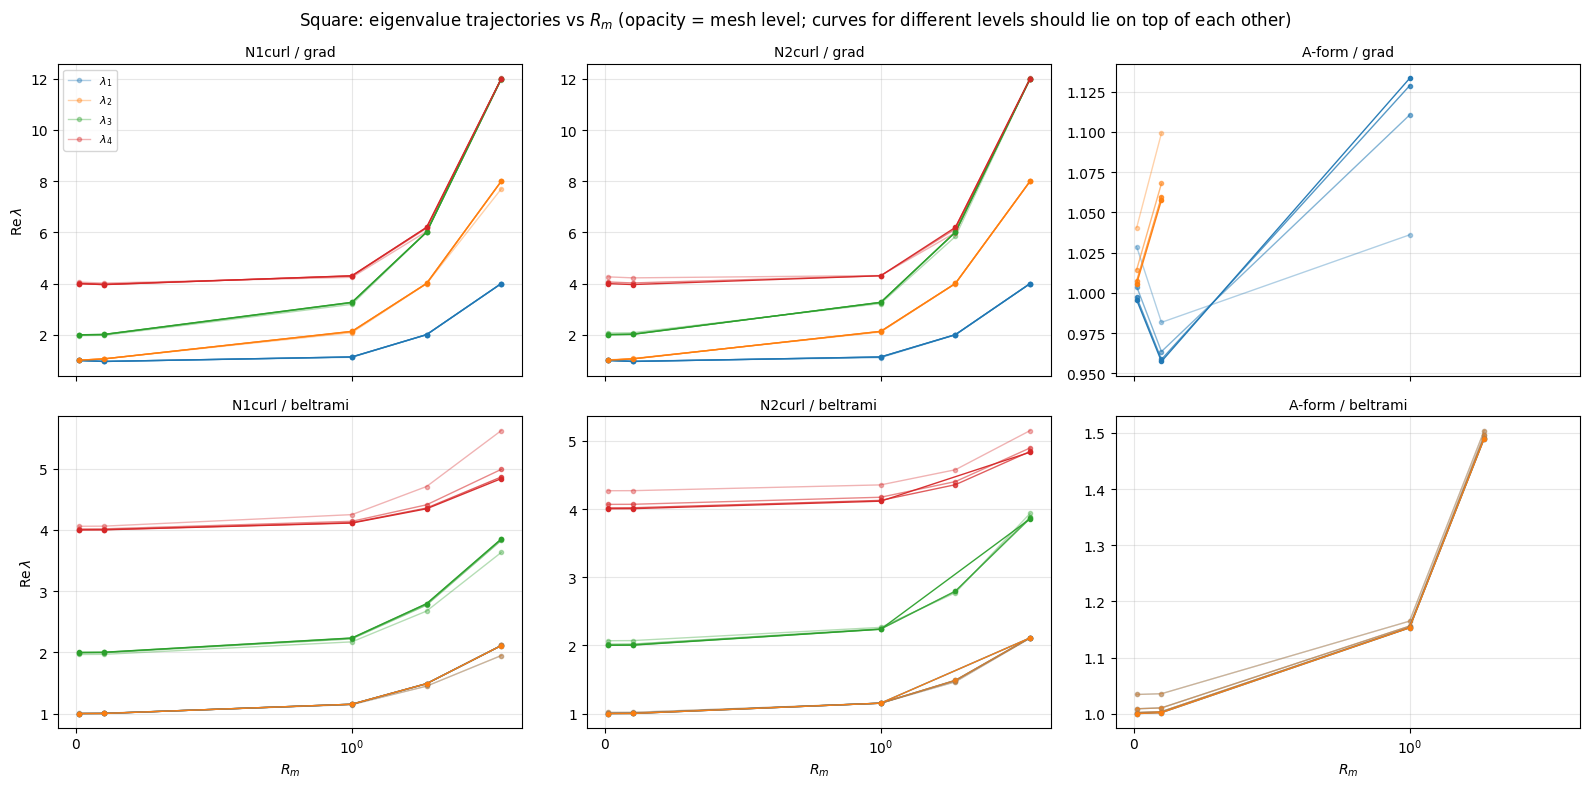

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
for j, sp in enumerate(SPACES):
    for i, wd in enumerate(WINDS):
        ax = axes[i, j]
        g = df_sq[(df_sq.space == sp) & (df_sq.wind == wd) & (df_sq.status == "ok")]
        for lvl, gl in g.groupby("level"):
            s = gl[gl.k < 4].groupby("Rm").re.apply(list)
            for k in range(4):
                y = [v[k] if len(v) > k else np.nan for v in s]
                ax.plot(s.index, y, marker="o", ms=3, lw=1,
                        alpha=0.35 + 0.2 * lvl,
                        color=f"C{k}", label=f"$\\lambda_{k+1}$" if lvl == 0 else None)
        ax.set_xscale("symlog", linthresh=1)
        ax.set_title(f"{sp} / {wd}", fontsize=10)
        ax.grid(alpha=0.3)
        if i == 1: ax.set_xlabel("$R_m$")
        if j == 0: ax.set_ylabel(r"$\mathrm{Re}\,\lambda$")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Square: eigenvalue trajectories vs $R_m$ (opacity = mesh level; "
             "curves for different levels should lie on top of each other)")
plt.tight_layout(); plt.show()

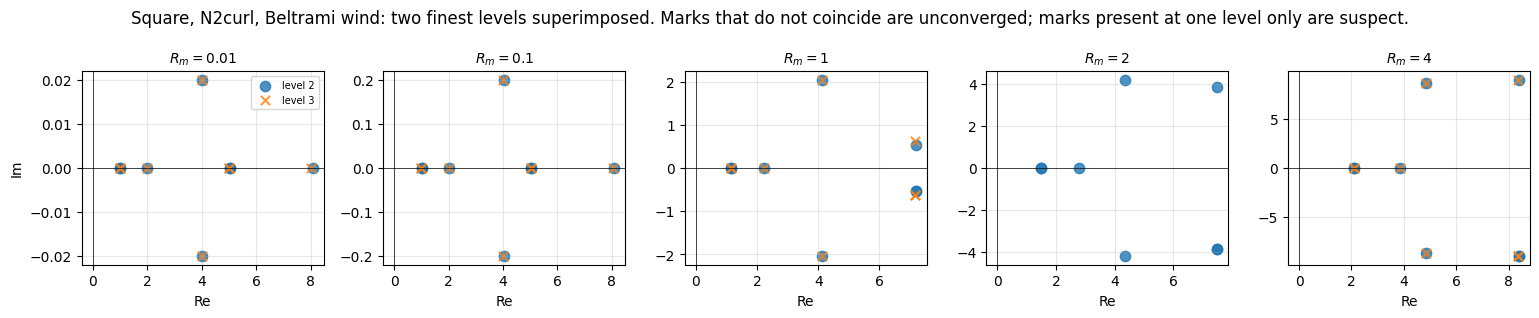

In [17]:
# Spectra in the complex plane at the finest level, one panel per Rm.
fine = df_sq.level.max()
g = df_sq[(df_sq.space == "N2curl") & (df_sq.wind == "beltrami")
          & (df_sq.status == "ok") & (df_sq.level >= fine - 1)]
fig, axes = plt.subplots(1, len(RM_LIST), figsize=(3.1 * len(RM_LIST), 3.2), sharey=False)
for ax, Rm in zip(np.atleast_1d(axes), RM_LIST):
    for lvl, mk, sz in ((fine - 1, "o", 55), (fine, "x", 45)):
        s = g[(g.Rm == Rm) & (g.level == lvl)]
        ax.scatter(s.re, s.im, marker=mk, s=sz, alpha=0.8, label=f"level {lvl}")
    ax.axhline(0, lw=0.5, color="k"); ax.axvline(0, lw=0.5, color="k")
    ax.set_title(f"$R_m={Rm}$", fontsize=10); ax.grid(alpha=0.3); ax.set_xlabel(r"Re")
np.atleast_1d(axes)[0].set_ylabel(r"Im"); np.atleast_1d(axes)[0].legend(fontsize=7)
fig.suptitle("Square, N2curl, Beltrami wind: two finest levels superimposed. "
             "Marks that do not coincide are unconverged; marks present at one level only are suspect.")
plt.tight_layout(); plt.show()

## B. L-shape

Reentrant corner of interior angle $3\pi/2$, so the leading eigenfunction has an $r^{2/3}$ singularity
and the expected rate is $2\cdot\tfrac23=\tfrac43\approx1.33$, not 2. That is already visible at
$R_m=1$ in `L-Shaped.ipynb` (1.16 and climbing). The question here is whether the corner rate and the
$R_m$ effect are independent, or whether they compound.

Reference at $R_m=0$: $\lambda_1 = 1.4756218450$.

In [18]:
lsh_hier = MeshHierarchy(make_Lshape_mesh(n=4, diagonal="crossed", structured=True), 3)
print("L-shape levels:", [(m.num_cells(), round(mesh_h(m), 4)) for m in lsh_hier])

L_SPACES = {k: SPACES[k] for k in ("N1curl", "N2curl")}
df_L = rm_sweep(lsh_hier, L_SPACES, WINDS, RM_LIST, domain="lshape")
df_L.to_csv("rm_sweep_lshape.csv", index=False)

show(spectrum_summary(df_L), "L-SHAPE - finest level summary")
show(rate_table(df_L), "L-SHAPE - observed rates (expect ~1.33 for the corner mode, 2.0 for the rest)")

L-shape levels: [(192, 0.25), (768, 0.125), (3072, 0.0625), (12288, 0.0312)]
done: lshape N1curl grad
done: lshape N1curl beltrami
  FAILED  N2curl  grad       Rm=4      level=1  ConvergenceError
done: lshape N2curl grad
  FAILED  N2curl  beltrami   Rm=0.01   level=1  ConvergenceError
  FAILED  N2curl  beltrami   Rm=1      level=1  ConvergenceError
  FAILED  N2curl  beltrami   Rm=2      level=1  ConvergenceError
  FAILED  N2curl  beltrami   Rm=4      level=1  ConvergenceError
  FAILED  N2curl  beltrami   Rm=4      level=3  ConvergenceError
done: lshape N2curl beltrami
L-SHAPE - finest level summary


,space,wind,Rm,Rm_h,min_Re,max_absIm,n_complex,n_zero,lam1,drift_h/2
0,N1curl,grad,0.01,0.00031,1.47351,0.00000,0,0,1.47351,0.01909
1,N1curl,grad,0.10,0.00312,1.47270,0.00000,0,0,1.47270,0.01909
2,N1curl,grad,1.00,0.03125,1.39736,0.00000,0,0,1.39736,0.01853
3,N1curl,grad,2.00,0.06250,1.21611,0.00000,0,0,1.21611,0.01812
4,N1curl,grad,4.00,0.12500,0.79791,0.00000,0,0,0.79791,0.02383
5,N1curl,beltrami,0.01,0.00031,1.47350,0.01838,2,0,1.47350,0.01909
6,N1curl,beltrami,0.10,0.00312,1.47145,0.18373,2,0,1.47145,0.01921
7,N1curl,beltrami,1.00,0.03125,1.29866,1.81349,5,0,1.29866,0.02297
8,N1curl,beltrami,2.00,0.06250,0.98687,3.53172,6,0,0.98687,0.01633
9,N1curl,beltrami,4.00,0.12500,0.57044,8.74995,6,0,0.57044,0.02079


L-SHAPE - observed rates (expect ~1.33 for the corner mode, 2.0 for the rest)


,space,wind,Rm,Rm_h(fine),rate_l1,rate_l2,rate_l3,rate_l4,rate_l5
0,N1curl,grad,0.01,0.00031,1.29525,3.29317,1.97945,1.97925,1.97267
1,N1curl,grad,0.10,0.00312,1.29520,3.11501,1.98028,1.97832,1.97102
2,N1curl,grad,1.00,0.03125,1.29190,1.54216,1.98626,1.95707,1.87297
3,N1curl,grad,2.00,0.06250,1.30175,1.71257,1.99148,2.12071,1.78621
4,N1curl,grad,4.00,0.12500,1.44346,1.83314,1.95255,1.70080,2.02392
5,N1curl,beltrami,0.01,0.00031,1.29525,3.29254,1.97935,1.97935,1.97328
6,N1curl,beltrami,0.10,0.00312,1.29480,3.08084,1.97928,1.97928,2.03696
7,N1curl,beltrami,1.00,0.03125,1.26708,1.34110,1.97164,1.97164,1.59311
8,N1curl,beltrami,2.00,0.06250,1.31264,0.18718,2.17326,2.17326,1.57952
9,N1curl,beltrami,4.00,0.12500,1.63250,2.35908,1.94386,1.94386,1.48912


In [20]:
# lambda_1 against the literature value at Rm = 0.
LSHAPE_LAM1 = 1.4756218450
g = df_L[(df_L.Rm == 0) & (df_L.k == 0) & (df_L.status == "ok")]
t = g.pivot_table(index="level", columns="space", values="re")
t["err_N2curl"] = (t["N2curl"] - LSHAPE_LAM1).abs()
show(t, f"L-SHAPE, Rm=0: lambda_1 vs exact {LSHAPE_LAM1}")

KeyError: 'N2curl'

## C. Annulus — Theorems 4 and 5

$b_1 = 1$, so the harmonic space is one dimensional.

* **Theorem 4**: the number of zero eigenvalues is at least the Betti number, so $\ge 1$.
* **Theorem 5**: as $R_m$ increases it becomes *exactly* the Betti number — equivalently, decreasing
  $\varepsilon$ should stop the count from exceeding 1.

`Annulus.ipynb` confirms exactly one zero at $R_m=1$ for three winds, which is consistent with both
but discriminates between neither. Sweeping $R_m$ is what separates them.

In [21]:
ann_hier = annulus_hierarchy(nlevels=2, inner_radius=0.5, outer_radius=1.0, maxh=0.2)
print("annulus levels:", [(m.num_cells(), round(mesh_h(m), 4)) for m in ann_hier])

# A wind that respects the geometry: azimuthal, plus the gradient field for the King check.
def w_azimuthal(mesh):
    x, y = SpatialCoordinate(mesh)
    return as_vector([-y, x])

ANN_WINDS = {"azimuthal": w_azimuthal, "grad": w_grad}

df_A = rm_sweep(ann_hier, L_SPACES, ANN_WINDS, RM_LIST, domain="annulus", n_keep=10)
df_A.to_csv("rm_sweep_annulus.csv", index=False)

show(spectrum_summary(df_A), "ANNULUS - finest level summary  (n_zero is the Theorem 4/5 count)")

annulus levels: [(144, 0.2573), (576, 0.1286), (2304, 0.0643)]
  FAILED  N1curl  azimuthal  Rm=1      level=0  ConvergenceError
  FAILED  N1curl  azimuthal  Rm=1      level=1  ConvergenceError
  FAILED  N1curl  azimuthal  Rm=1      level=2  ConvergenceError
  FAILED  N1curl  azimuthal  Rm=2      level=0  ConvergenceError
  FAILED  N1curl  azimuthal  Rm=2      level=1  ConvergenceError
  FAILED  N1curl  azimuthal  Rm=2      level=2  ConvergenceError
  FAILED  N1curl  azimuthal  Rm=4      level=0  ConvergenceError
  FAILED  N1curl  azimuthal  Rm=4      level=1  ConvergenceError
  FAILED  N1curl  azimuthal  Rm=4      level=2  ConvergenceError
done: annulus N1curl azimuthal
done: annulus N1curl grad
  FAILED  N2curl  azimuthal  Rm=1      level=0  ConvergenceError
  FAILED  N2curl  azimuthal  Rm=1      level=1  ConvergenceError
  FAILED  N2curl  azimuthal  Rm=1      level=2  ConvergenceError
  FAILED  N2curl  azimuthal  Rm=2      level=0  ConvergenceError
  FAILED  N2curl  azimuthal  Rm=2  

,space,wind,Rm,Rm_h,min_Re,max_absIm,n_complex,n_zero,lam1,drift_h/2
0,N1curl,azimuthal,0.01,0.00064,1.83512,0.01000,2,0,1.83512,0.00001
1,N1curl,azimuthal,0.10,0.00643,1.83512,0.09998,2,0,1.83512,0.00001
2,N1curl,grad,0.01,0.00064,1.82974,0.00000,0,0,1.82974,0.00001
3,N1curl,grad,0.10,0.00643,1.78188,0.00000,0,0,1.78188,0.00009
4,N1curl,grad,1.00,0.06432,1.35322,0.00000,0,0,1.35322,0.00043
5,N1curl,grad,2.00,0.12863,0.97490,0.00000,0,0,0.97490,0.00029
6,N1curl,grad,4.00,0.25726,0.47114,0.00000,0,0,0.47114,0.00086
7,N2curl,azimuthal,0.01,0.00064,1.83705,0.01000,2,0,1.83705,0.00550
8,N2curl,azimuthal,0.10,0.00643,1.83705,0.10000,2,0,1.83705,0.00550
9,N2curl,grad,0.01,0.00064,1.83167,0.00000,0,0,1.83167,0.00550


In [22]:
# Zero-mode count against Rm and mesh level, at several tolerances -- the count is
# tolerance sensitive, so quoting one number without the tolerance is not meaningful.
ok = df_A[df_A.status == "ok"]
rows = []
for tol in (1e-10, 1e-8, 1e-6, 1e-4):
    for (sp, wd, Rm, lvl), g in ok.groupby(["space", "wind", "Rm", "level"]):
        rows.append({"tol": tol, "space": sp, "wind": wd, "Rm": Rm, "level": lvl,
                     "n_zero": int(((g.re.abs() + g.im.abs()) < tol).sum())})
z = pd.DataFrame(rows).pivot_table(index=["space", "wind", "Rm"],
                                   columns=["tol", "level"], values="n_zero")
show(z, "ANNULUS: count of |lambda| < tol.  b_1 = 1, so Theorem 4 says >= 1, Theorem 5 says -> exactly 1")

ANNULUS: count of |lambda| < tol.  b_1 = 1, so Theorem 4 says >= 1, Theorem 5 says -> exactly 1


tol                   1.000000e-10           1.000000e-08           1.000000e-06           1.000000e-04          
level                            0    1    2            0    1    2            0    1    2            0    1    2
space  wind      Rm                                                                                              
N1curl azimuthal 0.01          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0
                 0.10          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0
       grad      0.01          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0
                 0.10          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0
                 1.00          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0
                 2.00          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0
                 4.00          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0
N2curl azimuthal 0.01          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0
                 0.10          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0
       grad      0.01          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0
                 0.10          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0
                 1.00          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0
                 2.00          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0
                 4.00          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0          0.0  0.0  0.0

## D. FEEC vs non-FEEC control at high $R_m$

`Baseline Validation` already shows the nodal (non-subcomplex) space producing three spurious limits
at $R_m=0$: $6.000$, $20.422$, $23.747$. The interesting question is whether the FEEC spaces stay
clean as $R_m$ grows, or whether they eventually pollute too. This is the cell most likely to produce
the first genuine failure in the FEEC-conforming discretisation.

In [ ]:
CTRL = dict(SPACES)
CTRL["nodal"] = (make_nodal, B_formulation_2d1k, bcs_nodal, True)

df_C = rm_sweep(sq_hier, CTRL, {"beltrami": w_beltrami},
                [0, 10, 100, 1000, 10000], domain="square-control", n_keep=10)
df_C.to_csv("rm_sweep_control.csv", index=False)

show(spectrum_summary(df_C), "CONTROL - FEEC vs nodal, finest level")

In [ ]:
# Side-by-side eigenvalues at the finest level. A limit that appears in the nodal
# column with no partner in either FEEC column is a spurious mode.
fine = df_C.level.max()
g = df_C[(df_C.level == fine) & (df_C.status == "ok")]
for Rm in sorted(g.Rm.unique()):
    t = (g[g.Rm == Rm]
         .pivot_table(index="k", columns="space", values="re")
         .join(g[g.Rm == Rm].pivot_table(index="k", columns="space", values="im")
               .add_suffix(" (Im)")))
    show(t, f"CONTROL, Rm = {Rm}: eigenvalues by space, finest level")

## E. Where does it break?

Collapse everything into one picture: observed convergence rate against the mesh Peclet number
$R_m h$. If the standard expectation holds, the rates should sit at 2 (or $4/3$ on the L-shape)
while $R_m h \lesssim 1$ and fall off after that, and the fall-off should collapse onto a single
curve regardless of how $R_m$ and $h$ were traded off against each other.

In [ ]:
all_rates = pd.concat([rate_table(df_sq).assign(domain="square"),
                       rate_table(df_L).assign(domain="lshape"),
                       rate_table(df_A).assign(domain="annulus")],
                      ignore_index=True)
all_rates.to_csv("rm_sweep_rates.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
for (dom, sp), g in all_rates.groupby(["domain", "space"]):
    m = g["Rm_h(fine)"] > 0
    ax.plot(g.loc[m, "Rm_h(fine)"], g.loc[m, "rate_l1"], marker="o", lw=1.2,
            label=f"{dom} / {sp}")
ax.axhline(2.0, ls="--", c="k", lw=0.8)
ax.axhline(4 / 3, ls=":", c="k", lw=0.8)
ax.axvline(1.0, ls="--", c="r", lw=0.8)
ax.text(1.05, 0.15, "$R_m h = 1$", color="r", fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("$R_m h$ (finest level)")
ax.set_ylabel(r"observed rate for $\lambda_1$")
ax.set_title("Convergence rate against mesh Peclet number")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

show(all_rates.sort_values(["domain", "space", "Rm"]), "ALL DOMAINS - rate summary")

## Notes

**On the $R_m$ scaling.** If you want the $\varepsilon$-form numbers for a table, divide by $R_m$:
$\lambda_\varepsilon = \lambda_{R_m}/R_m$. Eigenvectors and every convergence rate are unchanged.

**On the A-formulation zero.** `bcs_A_2d1k` returns `[]`, so the CG space has no essential boundary
condition and the constants lie in the kernel. `drop_harmonic=True` filters the resulting exact
$\lambda=0$ here, but the real fix is the `CG x R` multiplier that is commented out in
`A_formulation_2d1k` — with that in place the gauge is fixed properly and the zero disappears on its own.

**On the rate columns.** `observed_rate` estimates the limit by Aitken extrapolation and then drops
the finest level before fitting. Passing `exact_eigs=eigs[-1]`, as `Annulus.ipynb` and `PacMan.ipynb`
currently do, makes the last error exactly zero and the second-to-last artificially small, which is
where those 2.49–2.53 rates come from. The true rate in those tables is the ~2.05–2.15 in the middle
columns.

**If nothing here breaks either**, the next places to look, in order:

1. Move the Heaviside jump off the mesh lines. `sign(x - pi/2)` with $x_0=\pi/2$ sits exactly on a
   grid line of every `SquareMesh(N, ...)` and every `MeshHierarchy` refinement, so the wind is
   mesh-piecewise-constant — the best case, not the worst. Use $x_0 = \pi/\sqrt5$ or similar.
2. Replace the logarithmic corner singularity with an algebraic one. $\ln r$ is in every $L^p$ *and*
   in BMO, so it barely misses $L^\infty$. Use $r^{-\alpha}$ and sweep $\alpha$ through the critical
   exponent — `get_wind(4)` in `functions.py` already has a $(r-1.5)^{-3/2}$ field and is never called.
3. Sweep the shift-invert target, or dense-solve the coarse meshes. With `eps_target: 0.95` fixed you
   only ever see the eigenvalues near 0.95; pollution can appear anywhere.
4. $p$-refinement — everything so far is `degree=1`.
5. Pseudospectra. At high $R_m$ the operator is strongly non-normal, and the resolvent norm will show
   instability long before the eigenvalues visibly move.